# Exporting Results

In [1]:
#pip install numpy pandas matplotlib seaborn flopy geopandas shapely pyproj contextily

In [2]:
import os
import numpy as np
import flopy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # For histograms/kde plots
import geopandas as gpd # For spatial DataFrames (shapefiles/KML)
from shapely.geometry import Point, LineString # For geometry creation
import pyproj # For coordinate reference system handling
import contextily as ctx # For satellite basemaps
import zipfile # For creating KMZ files
from concurrent.futures import ThreadPoolExecutor # For parallel processing (used in your script)
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting, if not already imported via matplotlib
from rasterio.crs import CRS

# access simulation
# Define the bed elevation for filtering particles
bed_elevation = 1599.8125  # Defined in notebook
ncol = 431 # Defined in notebook
nrow = 385 # Defined in notebook

#\Users\u4eeevmq\Documents\Python\HP_workspace
# Define the workspace and file names
workspace = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace" # Defined in notebook
workspace_gwf = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace" # Defined in notebook

model_name = "Hyporheic_Project_mp"  # Defined in notebook
gwf_model_name = "gwf_model"  # Defined in notebook
#    r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace\Hyporheic_Project_mp_backward.mppth"
# Correct the simulation workspace path
model_ws = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace" # Defined in notebook

# Load the river cells from the CSV file
river_cells_csv = "C:\\Users\\u4eeevmq\\Documents\\Python\\HyporheicFloPy\\river_cells.csv"  # Defined in notebook

# Projection file
hec_ras_crs = "C:\\Users\\u4eeevmq\\Documents\\Python\\HyporheicFloPy\\CH00365\\RAS\\GIS_Data\\102739_TX_central.prj"

In [3]:
# Access Results of the Simulation
# Load the MODFLOW 6 simulation
sim = flopy.mf6.MFSimulation.load(sim_ws=workspace_gwf)
print(sim.model_names)

# Access the groundwater flow (GWF) model
gwf = sim.get_model("gwf_model")  # Replace "gwf_model" with your model name if different

# Get DIS package and idomain array
dis = gwf.get_package("DIS")
idomain = dis.idomain.array  # shape: (nlay, nrow, ncol)

# Load the head file
hds = flopy.utils.HeadFile(f"{model_ws}\{gwf_model_name}.hds")

# Get the head array (last time step if transient)
head_array = hds.get_data()
if head_array.ndim == 4:
    head_array = head_array[-1]  # Use heads from the last time step

def get_head(row):
    try:
        return head_array[int(row['layer']), int(row['row']), int(row['col'])]
    except Exception:
        return np.nan

# Get model grid information
xorigin = dis.xorigin  # Access the numerical value from MFScalar
yorigin = dis.yorigin
delr = dis.delr.array  # Column widths
delc = dis.delc.array  # Row heights

print(f"delr: {delr}")
print(f"delc: {delc}")

# Calculate spatial extents
x_min = xorigin.data  # Access the numerical value from MFScalar
x_max = xorigin.data + delr.sum()  # Access data and perform addition
y_min = yorigin.data  # Access the numerical value from MFScalar
y_max = yorigin.data + delc.sum()  # Access data and perform addition

extent = [x_min, x_max, y_min, y_max]
print(f"Spatial Extent: {extent}")

# Model grid shape
nlay, nrow, ncol = gwf.modelgrid.shape  # or define manually

# Debugging: Check a known of the head array
# head_value = head_array[0, 132, 266] # Change value to known particle location
# print(f"Head Value at (k={k}, j={j}, i={i}): {head_value}")

<>:14: DeprecationWarning: invalid escape sequence '\{'
<>:14: DeprecationWarning: invalid escape sequence '\{'
C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_26344\2502637471.py:14: DeprecationWarning: invalid escape sequence '\{'
  hds = flopy.utils.HeadFile(f"{model_ws}\{gwf_model_name}.hds")


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package chd...
    loading package oc...
  loading solution package gwf_model...
['gwf_model']
delr: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5

In [4]:
# Define the MODPATH 7 pathline and endpoint files
## Forward pathline and endpoint files
f_pathline_file = os.path.join(workspace, model_name + "_forward.mppth")
endpoint_file = os.path.join(workspace, model_name + "_forward.mpend")

## Backward pathline and endpoint files
#b_pathline_file = os.path.join(workspace, model_name + "_backward.mppth")
#b_endpoint_file = os.path.join(workspace, model_name + "_backward.mpend")

In [5]:
# Load the river cells from the CSV file
river_cells_df = pd.read_csv(river_cells_csv)

# Convert the DataFrame back to a list of tuples
river_cells = list(river_cells_df.itertuples(index=False, name=None))

print(f"✅ Loaded {len(river_cells)} river cells from {river_cells_csv}")
print(f"River cells: {river_cells}")

# Extract numerical values from xorigin and yorigin
xorigin_value = xorigin.data  
yorigin_value = yorigin.data  

# Print the origin values for verification
print(f"xorigin: {xorigin_value}, yorigin: {yorigin_value}")

# Print the delr and delc arrays for verification
print(f"delr: {delr}, delc: {delc}")

# Convert river cell row/col indices to real-world coordinates
river_cell_coords = [
    (
        sum(delr[:cell[2]]) + delr[cell[2]] / 2 + xorigin_value,  # X-coordinate (center)
        sum(delc[:cell[1]]) + delc[cell[1]] / 2 + yorigin_value   # Y-coordinate (center)
    )
    for cell in river_cells
]

# Convert to a set for quick lookup
river_cell_coords_set = set(river_cell_coords)

# Print a few converted coordinates for verification
print("Example converted river cell coordinates:", list(river_cell_coords_set)[:5])
print(f"delr: {delr}, delc: {delc}")

✅ Loaded 1255 river cells from C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\river_cells.csv
River cells: [(0, 130, 267, 1600.7779541015625), (0, 131, 266, 1600.785888671875), (0, 131, 267, 1600.7843017578125), (0, 131, 268, 1600.78125), (0, 131, 269, 1600.7799072265625), (0, 131, 270, 1600.77783203125), (0, 132, 266, 1600.7908935546875), (0, 132, 267, 1600.7879638671875), (0, 132, 268, 1600.78369140625), (0, 132, 269, 1600.781982421875), (0, 132, 270, 1600.7791748046875), (0, 132, 271, 1600.7779541015625), (0, 132, 272, 1600.7760009765625), (0, 132, 273, 1600.7747802734375), (0, 132, 274, 1600.7735595703125), (0, 133, 265, 1600.81591796875), (0, 133, 266, 1600.8026123046875), (0, 133, 267, 1600.796875), (0, 133, 268, 1600.7894287109375), (0, 133, 269, 1600.78662109375), (0, 133, 270, 1600.7823486328125), (0, 133, 271, 1600.7803955078125), (0, 133, 272, 1600.7774658203125), (0, 133, 273, 1600.776123046875), (0, 133, 274, 1600.774169921875), (0, 133, 275, 1600.773193359375), (0, 133

No match (Outlier): (np.float32(1337.3253), np.float32(1270.0))
No match (Outlier): (np.float32(1338.1483), np.float32(1270.0))
No match (Outlier): (np.float32(1350.0), np.float32(1269.5836))
No match (Outlier): (np.float32(1350.0), np.float32(1268.5546))
No match (Outlier): (np.float32(1337.3253), np.float32(1270.0))
No match (Outlier): (np.float32(1350.0), np.float32(1269.9292))
No match (Outlier): (np.float32(1350.0), np.float32(1268.7175))
No match (Outlier): (np.float32(1350.0), np.float32(1265.1394))
No match (Outlier): (np.float32(1354.803), np.float32(1265.0))
No match (Outlier): (np.float32(1370.0), np.float32(1264.8383))
No match (Outlier): (np.float32(1370.0), np.float32(1264.5079))
No match (Outlier): (np.float32(1370.0), np.float32(1263.5564))
No match (Outlier): (np.float32(1337.3253), np.float32(1270.0))
No match (Outlier): (np.float32(1337.3254), np.float32(1270.0))
No match (Outlier): (np.float32(1350.0), np.float32(1268.9812))
No match (Outlier): (np.float32(1350.0), 

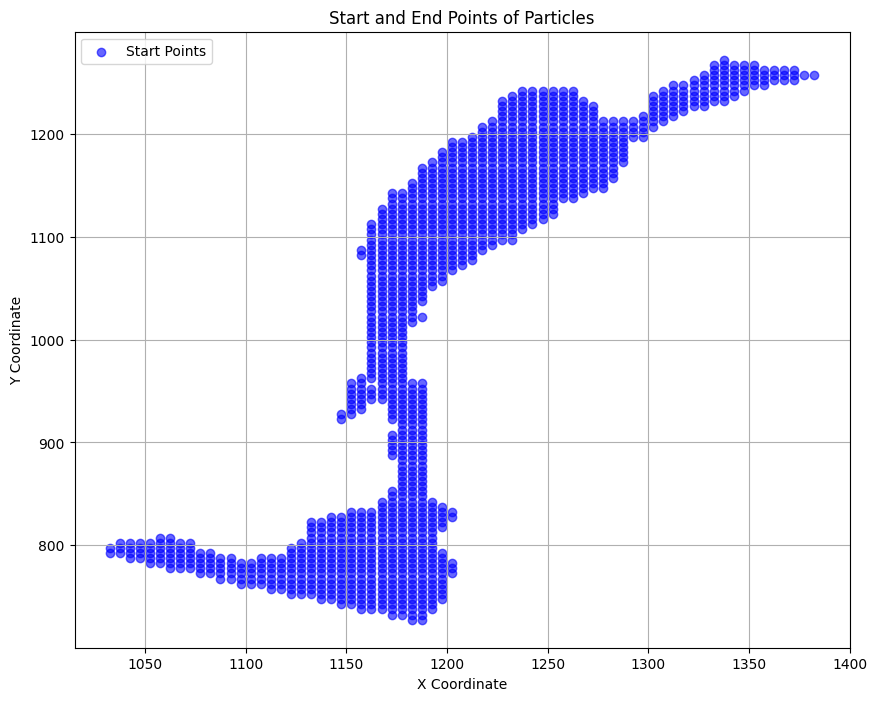

In [6]:
# Read forward endpoint data
endpoint_reader = flopy.utils.EndpointFile(endpoint_file)
endpoints = endpoint_reader.get_alldata()

# Filter particles that end at or above the bed elevation and do not end in the same start cell
filtered_particles = [
    ep for ep in endpoints
    if (
        ep['z'] >= bed_elevation and
        (ep['x'], ep['y']) != (ep['x0'], ep['y0']) and
        abs(ep['z'] - ep['z0']) > 0  # At least 5 feet change in z
    )
]

# Filter particles that are within the river cells
# Initialize subsets
outliers = []
hyporheic_particles = []

# Filter particles into subsets
for ep in filtered_particles:
    particle_coords = (ep['x'], ep['y'])
    if particle_coords in river_cell_coords_set:
        hyporheic_particles.append(ep)  # Add to hyporheic particles
        print(f"Match found (Hyporheic): {particle_coords}")
    else:
        outliers.append(ep)  # Add to outliers
        print(f"No match (Outlier): {particle_coords}")

# Print summary
print(f"Total hyporheic particles: {len(hyporheic_particles)}")
print(f"Total outliers: {len(outliers)}")

# Get the particle IDs of filtered particles
filtered_particle_ids = [ep['particleid'] for ep in filtered_particles]

# Convert particle IDs to plain Python integers
filtered_particle_ids = [int(ep['particleid']) for ep in filtered_particles]

print(f"Total particles ending at or above bed elevation: {len(filtered_particles)}")
print(f"Particle IDs ending at or above bed elevation: {filtered_particle_ids}")
print("Available fields in pathline data:", filtered_particles[0].dtype.names)

# Convert filtered_particle_ids into a list
particle_ids_list = list(filtered_particle_ids)

# Print the resulting list
print(particle_ids_list)

# Extract start and end points
start_points = [(ep['x0'], ep['y0'], ep['z0']) for ep in endpoints]  # Starting coordinates
end_points = [(ep['x'], ep['y'], ep['z']) for ep in endpoints]       # Ending coordinates

# Convert to NumPy arrays for easier manipulation
start_points = np.array(start_points)
end_points = np.array(end_points)

# Plot start and end points
plt.figure(figsize=(10, 8))
plt.scatter(start_points[:, 0], start_points[:, 1], c='blue', label='Start Points', alpha=0.6)
#plt.scatter(end_points[:, 0], end_points[:, 1], c='red', label='End Points', alpha=0.6)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Start and End Points of Particles')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Read forward pathline data only for selected particles
pathline_reader = flopy.utils.PathlineFile(f_pathline_file)

# Load pathline data for all particle IDs in the list
filtered_pathlines = []
for particle_id in particle_ids_list:
    filtered_pathlines.extend(pathline_reader.get_data(partid=particle_id))

# Print the total number of pathlines and the particle IDs list
print(f"Total pathlines corresponding to filtered particles: {len(filtered_pathlines)}")
print("Particle IDs List:", particle_ids_list)
print(type(filtered_pathlines))
print("Available fields in pathline data:", filtered_pathlines[0].dtype.names)

# Available fields in pathline data
column_names = [
    'particleid', 'particlegroup', 'sequencenumber', 'particleidloc', 'time',
    'x', 'y', 'z', 'k', 'node', 'xloc', 'yloc', 'zloc', 'stressperiod', 'timestep'
]

# Convert NumPy structured array to DataFrame and add column names
if isinstance(filtered_pathlines, list) and hasattr(filtered_pathlines[0], 'dtype'):
    filtered_pathlines_df = pd.DataFrame.from_records(filtered_pathlines, columns=column_names)

# Print the first few rows to check the structure
print(filtered_pathlines_df.head())

# Debugging: Check if all required fields are present
required_fields = ['x', 'y', 'z', 'time', 'k', 'particleid']
missing_fields = [field for field in required_fields if field not in filtered_pathlines_df.columns]
print("Missing fields:", missing_fields)

# Group pathlines by particle ID
grouped_pathlines = filtered_pathlines_df.groupby('particleid')

Total pathlines corresponding to filtered particles: 191285
Particle IDs List: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216,

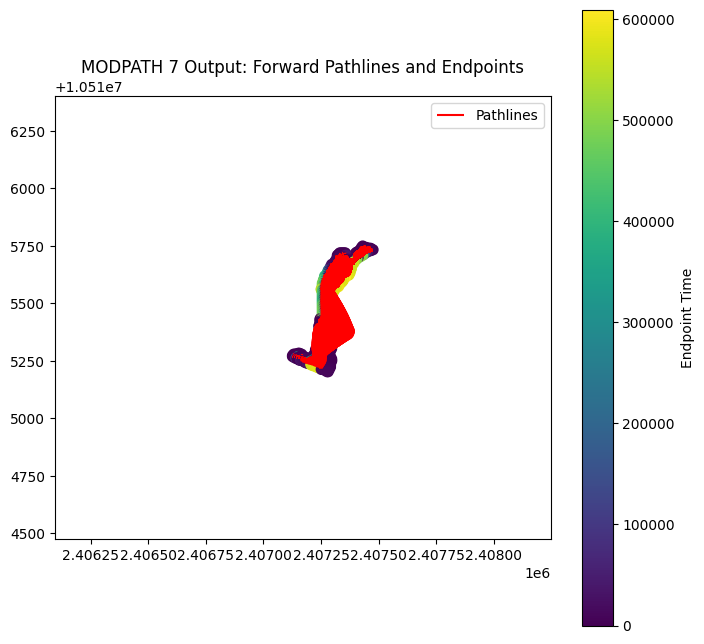

In [8]:
# Visualize forward pathlines and endpoints 
# Plot top view
plt.figure(figsize=(8, 8))
mm = flopy.plot.PlotMapView(model=gwf)

# Plot grid (optional, set lw=0 to hide grid lines)
mm.plot_grid(lw=0)

# Plot pathlines
mm.plot_pathline(filtered_pathlines_df, layer="all", colors="red", label="Pathlines")

# Plot endpoints (if available)
mm.plot_endpoint(endpoints, direction="starting", colorbar=True)

# Apply spatial extent for zooming
mm.ax.set_xlim(extent[0], extent[1])
mm.ax.set_ylim(extent[2], extent[3])

# Add title and legend
plt.title("MODPATH 7 Output: Forward Pathlines and Endpoints")
mm.ax.legend()
plt.show()

C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_26344\198189868.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lengths = grouped_pathlines.apply(pathline_length)


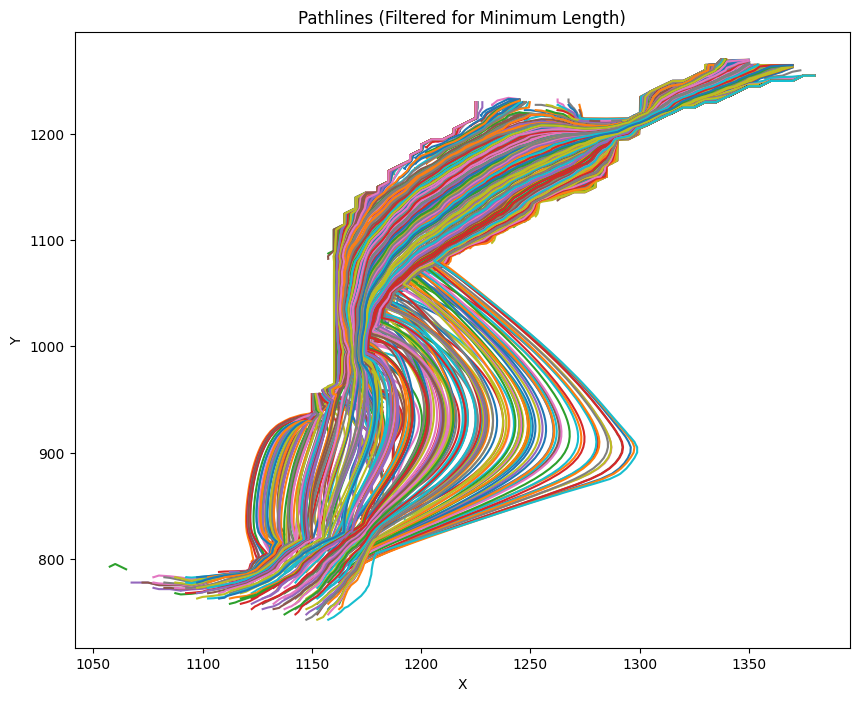

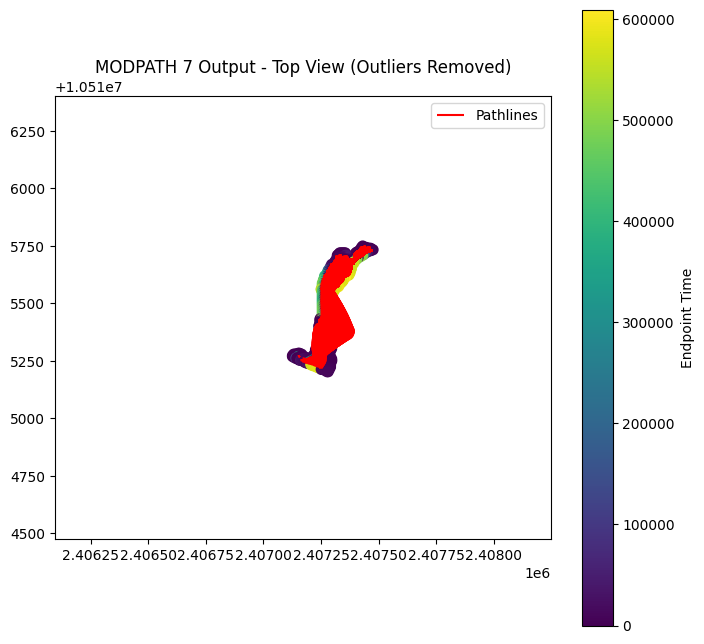

               x            y
414  1332.500000  1262.500000
415  1332.500000  1262.500488
416  1332.500122  1262.500977
417  1332.500122  1262.501343
418  1332.500244  1262.501953
xorigin: 2406093.51 xmax: 2408248.51
yorigin: 10514475.4 ymax: 10516400.4


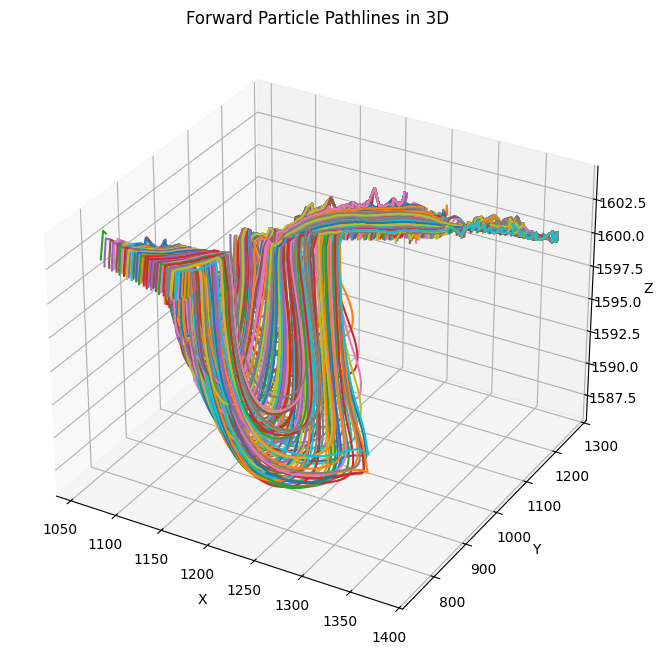

In [9]:
# Remove outliers from the pathlines (too short to be hyporheic space)
# Define your threshold (e.g., 2 cell widths)
n_cells = 2
mean_cell_width = (np.mean(delr) + np.mean(delc)) / 2
threshold_in_feet = n_cells * mean_cell_width   # n_cells = 1, 2, etc.
default_z_cell_size = 0.5  # Default z cell size in feet, adjust as needed

# Function to compute total pathline length for a group
def pathline_length(group):
    # Sort by 'time' to ensure correct order
    group = group.sort_values(by='time')
    x, y = group['x'].to_numpy(), group['y'].to_numpy()
    # Compute segment distances
    dist = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    return dist.sum()

# Compute lengths for all particles
lengths = grouped_pathlines.apply(pathline_length)

# Get particleids of pathlines longer than the threshold
long_path_particleids = lengths[lengths >= threshold_in_feet].index

# Filter the DataFrame to keep only long pathlines
filtered_long_pathlines_df = filtered_pathlines_df[filtered_pathlines_df['particleid'].isin(long_path_particleids)]

# (Optional) Re-plot using filtered_long_pathlines_df
grouped_long_pathlines = filtered_long_pathlines_df.groupby('particleid')

plt.figure(figsize=(10, 8))
for particle_id, group in grouped_long_pathlines:
    group = group.sort_values(by='time')
    x = group['x'].to_numpy()
    y = group['y'].to_numpy()
    plt.plot(x, y, label=f"Particle {particle_id}" if particle_id < 5 else "")

plt.title('Pathlines (Filtered for Minimum Length)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

xyz_tuples_per_particle = {}

for particle_id, group in grouped_long_pathlines:
    group = group.sort_values(by='time')
    x = group['x'].to_numpy()
    y = group['y'].to_numpy()
    z = group['z'].to_numpy()
    xyz_tuples = list(zip(x, y, z))  # List of (x, y, z) tuples for this pathline
    xyz_tuples_per_particle[particle_id] = xyz_tuples

    # Debugging: Plot pathlines
    # plt.plot(x, y, label=f"Particle {particle_id}" if particle_id < 5 else "") 

# Plot Filtered Forward Pathlines and Endpoints
# Plot top view
plt.figure(figsize=(8, 8))
mm = flopy.plot.PlotMapView(model=gwf)

# Plot grid (optional, set lw=0 to hide grid lines)
mm.plot_grid(lw=0)

# Plot pathlines
mm.plot_pathline(filtered_long_pathlines_df, layer="all", colors="red", label="Pathlines")

# Plot endpoints (if available)
mm.plot_endpoint(endpoints, direction="starting", colorbar=True)

# Apply spatial extent for zooming
mm.ax.set_xlim(extent[0], extent[1])
mm.ax.set_ylim(extent[2], extent[3])

# Add title and legend
plt.title("MODPATH 7 Output - Top View (Outliers Removed)")
mm.ax.legend()
plt.show()

# Debugging: Check data structure
print(filtered_long_pathlines_df[['x', 'y']].head())
print("xorigin:", x_min, "xmax:", x_min + delr.sum())
print("yorigin:", y_min, "ymax:", y_min + delc.sum())

# Visualize pathlines in 3D
# Group pathline data by 'particleid'
grouped_pathlines = filtered_long_pathlines_df.groupby('particleid')

# Initialize 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot pathlines as lines
for particle_id, group in grouped_pathlines:
    # Sort the group by 'time' or 'sequencenumber' to ensure correct line ordering
    group = group.sort_values(by='time')  # or 'sequencenumber'

    # Extract x, y, z coordinates
    x = group['x'].to_numpy()
    y = group['y'].to_numpy()
    z = group['z'].to_numpy()

    # Plot the line for this particle
    ax.plot(x, y, z, label=f"Particle {particle_id}" if particle_id < 5 else "")  # Label only first few particles for clarity

# Add labels, title, and legend
ax.set_title("Forward Particle Pathlines in 3D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


Path Length (y-range, ft): mean=193.62, median=146.92, min=2.34, max=512.50
Path Width (x-range, ft): mean=127.49, median=132.50, min=0.95, max=267.50
Path Depth (z-range, ft): mean=3.62, median=1.16, min=0.03, max=17.94
3D Path Length (ft): mean=263.87, median=212.74, min=10.33, max=699.65


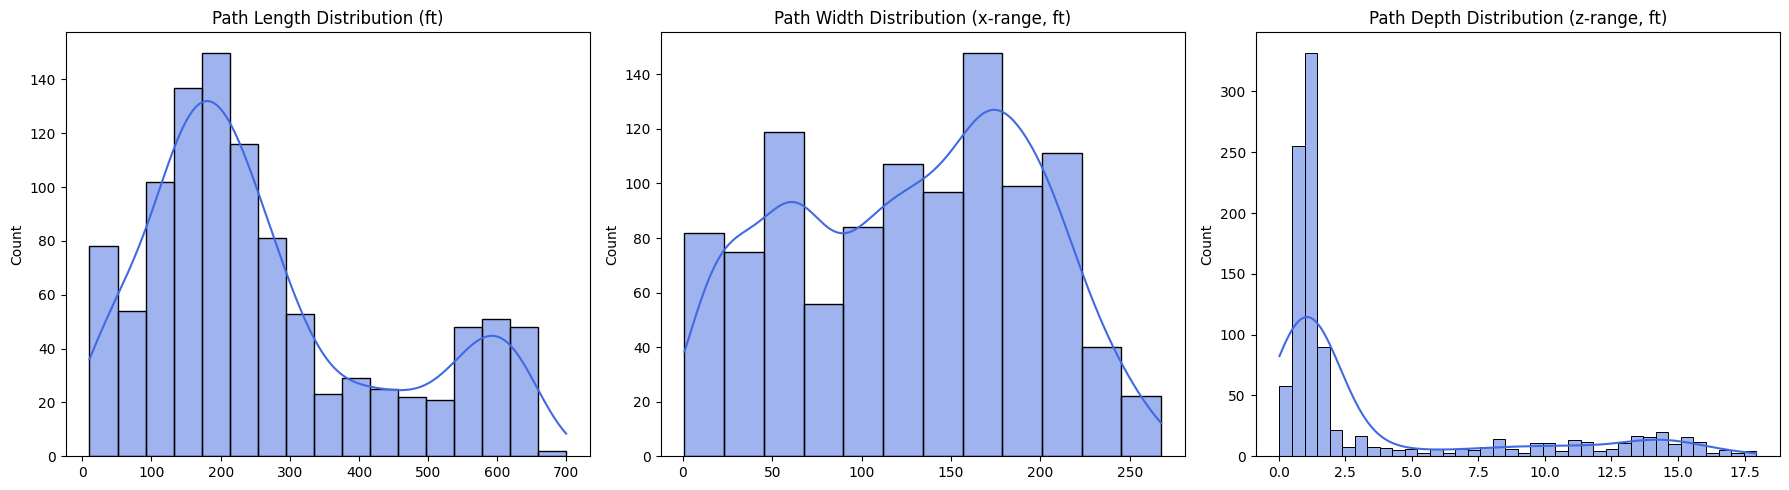

In [10]:
# Calculate forward path lengths, widths, and depth
lengths = []
widths = []
depths = []
path_lengths = []

for particle_id, group in grouped_pathlines:
    # Sort to ensure correct order
    group = group.sort_values(by='time')
    x = group['x'].to_numpy()
    y = group['y'].to_numpy()
    z = group['z'].to_numpy()

    # Path length: sum of 3D distances between consecutive points (optional, for reference)
    coords = np.stack((x, y, z), axis=1)
    diffs = np.diff(coords, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    path_length = dists.sum()

    # Length: range in y
    length = y.max() - y.min()
    # Width: range in x
    width = x.max() - x.min()
    # Height: range in z
    depth = z.max() - z.min()

    lengths.append(length)
    widths.append(width)
    depths.append(depth)
    path_lengths.append(path_length)  # Optional

# Convert to numpy arrays
lengths = np.array(lengths)
widths = np.array(widths)
depths = np.array(depths)
path_lengths = np.array(path_lengths)

# Calculate statistics
def print_stats(arr, name):
    print(f"{name}: mean={arr.mean():.2f}, median={np.median(arr):.2f}, min={arr.min():.2f}, max={arr.max():.2f}")

print_stats(lengths, "Path Length (y-range, ft)") # length in y-direction
print_stats(widths, "Path Width (x-range, ft)")
print_stats(depths, "Path Depth (z-range, ft)")
print_stats(path_lengths, "3D Path Length (ft)")  # Real length

# Plot distributions (white to blue gradient)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(path_lengths, kde=True, ax=axs[0], color='royalblue')
axs[0].set_title('Path Length Distribution (ft)')
sns.histplot(widths, kde=True, ax=axs[1], color='royalblue')
axs[1].set_title('Path Width Distribution (x-range, ft)')
sns.histplot(depths, kde=True, ax=axs[2], color='royalblue')
axs[2].set_title('Path Depth Distribution (z-range, ft)')
plt.tight_layout()
plt.show()

Example residence times: [ 762.71783  939.11053 1309.5042  1121.5673   322.07892]


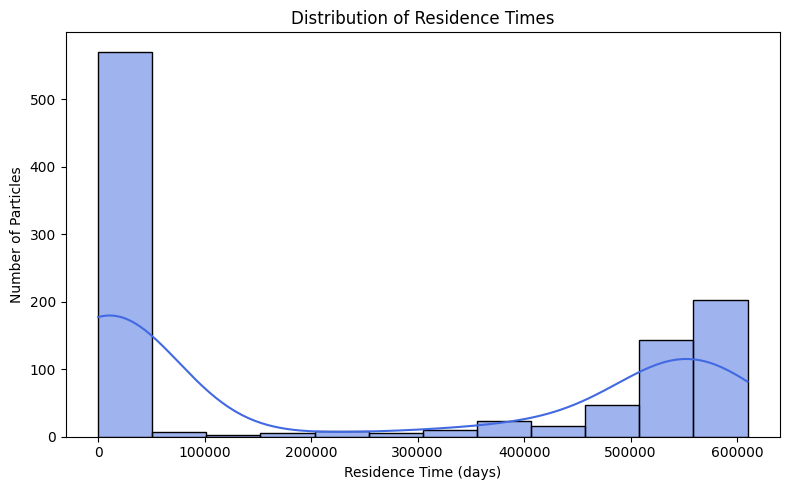

Mean residence time: 236650.66 days
Median residence time: 20495.95 days
Min residence time: 105.51 days
Max residence time: 609750.12 days


In [11]:
# Calculate forward particle residence times
# Compute residence time per particle (max time per unique particleid)
residence_times = (
    filtered_long_pathlines_df.groupby('particleid')['time'].max().to_numpy()
)

# Print a few to check
print("Example residence times:", residence_times[:5])

# Plot distribution of residence times
plt.figure(figsize=(8, 5))
sns.histplot(residence_times[(residence_times > 0) & (~np.isnan(residence_times))]
, kde=True, color='royalblue')
plt.xlabel('Residence Time (days)')
plt.ylabel('Number of Particles')
plt.title('Distribution of Residence Times')
plt.tight_layout()
plt.show()

# Statistics
print(f"Mean residence time: {np.mean(residence_times):.2f} days")
print(f"Median residence time: {np.median(residence_times):.2f} days")
print(f"Min residence time: {np.min(residence_times):.2f} days")
print(f"Max residence time: {np.max(residence_times):.2f} days")

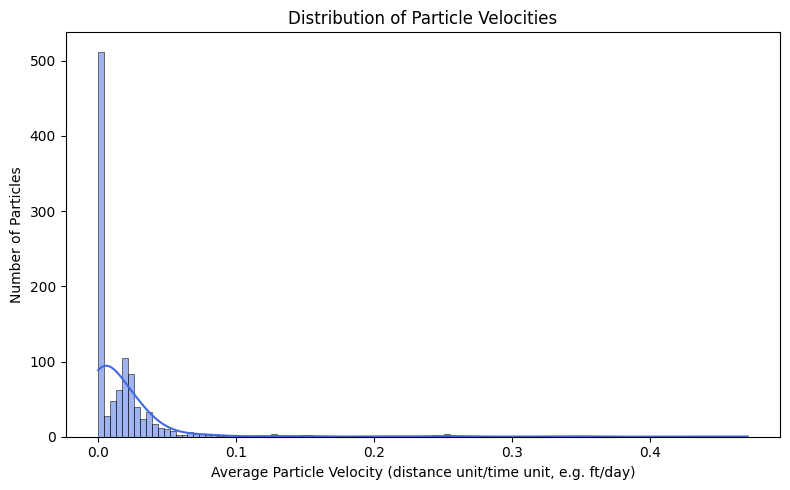

In [12]:
# Calculate forward particle velocities
# Initialize a list to store particle velocities
particle_velocities = []

for particle_id, group in filtered_long_pathlines_df.groupby('particleid'):
    group = group.sort_values(by='time')
    x, y, z = group['x'].to_numpy(), group['y'].to_numpy(), group['z'].to_numpy()
    coords = np.stack((x, y, z), axis=1)
    dists = np.linalg.norm(np.diff(coords, axis=0), axis=1)
    path_length = dists.sum()
    time_elapsed = group['time'].iloc[-1] - group['time'].iloc[0]  # or .max() - .min()
    if time_elapsed > 0:
        avg_velocity = path_length / time_elapsed
    else:
        avg_velocity = np.nan  # handle 0 time
    particle_velocities.append({'particleid': particle_id, 'path_length': path_length, 'time_elapsed': time_elapsed, 'avg_velocity': avg_velocity})

# Convert to DataFrame
velocities_df = pd.DataFrame(particle_velocities)

# Plot velocity distribution (assuming velocities_df['avg_velocity'] contains your velocities)
plt.figure(figsize=(8, 5))
sns.histplot(velocities_df['avg_velocity'].dropna(), kde=True, color='royalblue')
plt.xlabel('Average Particle Velocity (distance unit/time unit, e.g. ft/day)')
plt.ylabel('Number of Particles')
plt.title('Distribution of Particle Velocities')
plt.tight_layout()
plt.show()


In [ ]:
# Convert forward paticles from model space (ft from origin) to model grid space (nlay, nrow, ncol)
# Initialize binary presence array
binary_presence = np.zeros((nlay, nrow, ncol), dtype=int)

# Extract x, y, z coordinates from the filtered long pathlines DataFrame
x_local = filtered_long_pathlines_df['x'].values
y_local = filtered_long_pathlines_df['y'].values
x_spatial, y_spatial = gwf.modelgrid.get_coords(x_local, y_local)
z_array = filtered_long_pathlines_df['z'].values if 'z' in filtered_long_pathlines_df else [None]*len(filtered_long_pathlines_df)

def intersect_one(args):
    idx, x_s, y_s, z = args
    try:
        if z is not None and not np.isnan(z):
            k, j, i = gwf.modelgrid.intersect(x_s, y_s, z)
        else:
            k, j, i = gwf.modelgrid.intersect(x_s, y_s)
        return (k, j, i)
    except Exception:
        return (np.nan, np.nan, np.nan)

# Collect all intersection indices for each particle (TAKES 90 MINUTES)
with ThreadPoolExecutor() as executor:
    results = list(executor.map(intersect_one, zip(range(len(x_spatial)), x_spatial, y_spatial, z_array)))

# Attach to DataFrame
layers, rows, cols = zip(*results)
filtered_long_pathlines_df['layer'] = layers
filtered_long_pathlines_df['row'] = rows
filtered_long_pathlines_df['col'] = cols

# Mark binary presence for valid cells and print 
for k, j, i in results:
    if (not np.isnan(k)) and (not np.isnan(j)) and (not np.isnan(i)):
        k_int, j_int, i_int = int(k), int(j), int(i)
        if 0 <= k_int < nlay and 0 <= j_int < nrow and 0 <= i_int < ncol:
            binary_presence[k_int, j_int, i_int] = 1
            print(f"Particle intersects at layer {k_int}, row {j_int}, column {i_int}") # Comment this out to speed up processing

# Count intersected cells 
num_intersected_cells = np.sum(binary_presence)
print(f"Number of unique cells intersected by pathlines: {num_intersected_cells}")

# Preview DataFrame with new indices to ensure spatial mapping
print(filtered_long_pathlines_df[['x', 'y', 'z', 'layer', 'row', 'col']].head())

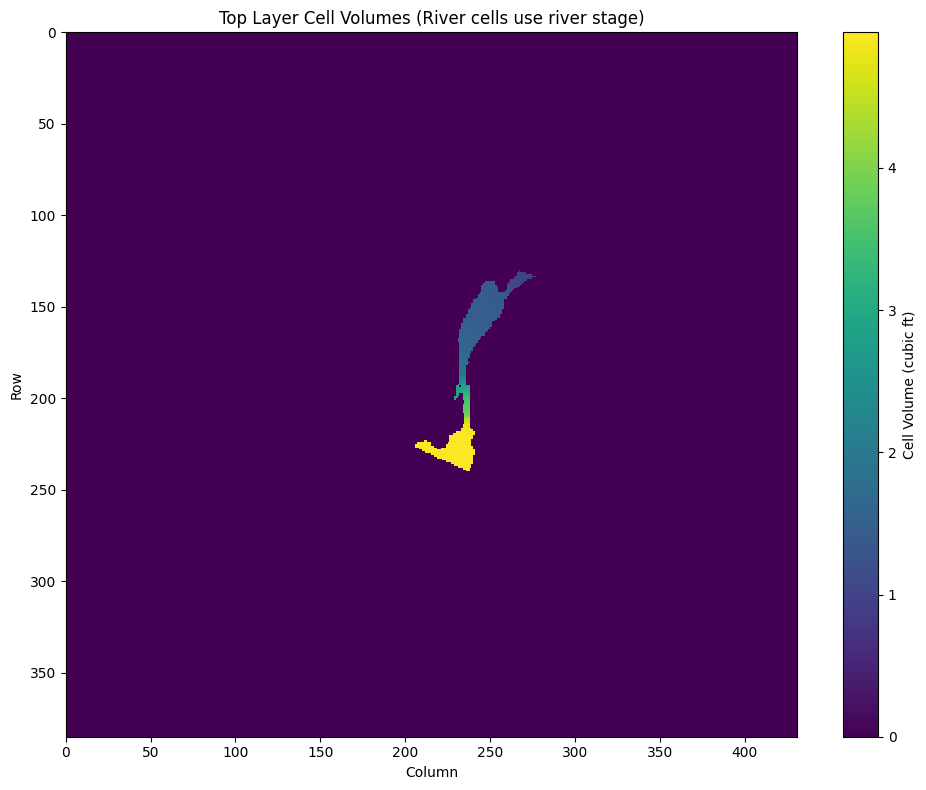

In [ ]:
# Calculate the volume of cells in the model grid
# Initialize cell volumes array
cell_volumes = np.zeros((nlay, nrow, ncol))

delr_mean = np.mean(delr)   # Use mean if delr is an array; otherwise just use delr
delc_mean = np.mean(delc)   # Use mean if delc is an array; otherwise just use delc

# Prepare river_stage array for the top layer
river_stage_array = np.zeros((nrow, ncol))

# Example: river_cells is a list of tuples like (layer, row, col, river_stage)
for cell in river_cells:
    k, j, i, stage = cell
    if k == 0:  # Only consider top layer
        river_stage_array[j, i] = stage

top = gwf.modelgrid.top  # shape: (nrow, ncol)
bot = gwf.modelgrid.botm[0, :, :]  # bottom of top layer, shape: (nrow, ncol)

# Where river_stage is present and >0, use it; otherwise use top
use_river = river_stage_array > 0
thickness_top = np.where(use_river, river_stage_array - bot, 0)
cell_volumes[0, :, :] = delr_mean * delc_mean * thickness_top

# Lower layers: uniform thickness
uniform_thickness = 0.5  # feet
for k in range(1, nlay):
    cell_volumes[k, :, :] = delr_mean * delc_mean * uniform_thickness

plt.figure(figsize=(10, 8))
c = plt.pcolormesh(thickness_top, cmap='viridis', shading='auto')
plt.colorbar(c, label='Cell Volume (cubic ft)')
plt.title('Top Layer Cell Volumes (River cells use river stage)')
plt.xlabel('Column')
plt.ylabel('Row')
plt.gca().invert_yaxis()  # To match typical model grid orientation (row 0 at top)
plt.tight_layout()
plt.show()

Minimum cell hyporheic volume: 0.00 cubic feet
Maximum cell hyporheic volume: 409.03 cubic feet
Maximum volume at cell (row, col): (np.int64(216), np.int64(236)), value: 409.03 cubic feet
Minimum volume at cell (row, col): (np.int64(121), np.int64(235)), value: 0.00 cubic feet


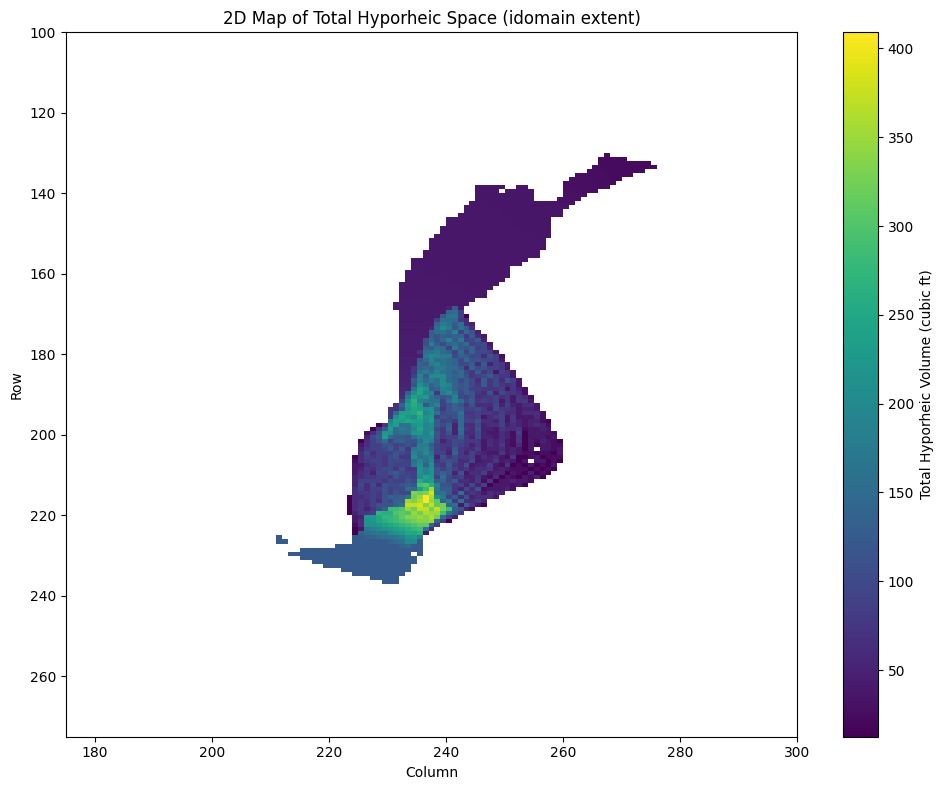

In [ ]:
# Calculate the volume of hyporheic space using forward pathlines
# Only count volumes where pathlines are present
hyporheic_volumes = cell_volumes * binary_presence

# Sum across all layers to get total volume at each (row, col)
total_vol_per_xy = np.sum(hyporheic_volumes, axis=0)  # shape: (nrow, ncol)
idomain = dis.idomain.array  # shape: (nlay, nrow, ncol)

# Mask out inactive cells (set volume to np.nan or mask)
masked_vol = np.where(idomain[0,:,:] == 1, total_vol_per_xy, np.nan)

min_vol = np.nanmin(masked_vol)
max_vol = np.nanmax(masked_vol)

print(f"Minimum cell hyporheic volume: {min_vol:.2f} cubic feet")
print(f"Maximum cell hyporheic volume: {max_vol:.2f} cubic feet")

max_loc = np.unravel_index(np.nanargmax(masked_vol), masked_vol.shape)
min_loc = np.unravel_index(np.nanargmin(masked_vol), masked_vol.shape)

print(f"Maximum volume at cell (row, col): {max_loc}, value: {max_vol:.2f} cubic feet")
print(f"Minimum volume at cell (row, col): {min_loc}, value: {min_vol:.2f} cubic feet")

# Extent for plotting
masked_vol_plot = np.ma.masked_less_equal(masked_vol, 0)  # mask 0 and below
plt.figure(figsize=(10, 8))
c = plt.pcolormesh(masked_vol_plot, cmap='viridis', shading='auto')
plt.colorbar(c, label='Total Hyporheic Volume (cubic ft)')
plt.title('2D Map of Total Hyporheic Space (idomain extent)')
plt.xlabel('Column')
plt.ylabel('Row')
plt.xlim(175, 300)
plt.ylim(100, 275)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Pathline point data for each particle
- Point File (total estimated water volume, hyporeheic volume, particle velocity, and flow rates, length of path at this point, elevation, hydraulic gradient at each point, time)

In [ ]:
# Calculate results along the pathlines for each segment
# hyporheic volumes
hyporheic_vols = []
for k, j, i in zip(filtered_long_pathlines_df['layer'], filtered_long_pathlines_df['row'], filtered_long_pathlines_df['col']):
    if not np.isnan(k) and not np.isnan(j) and not np.isnan(i):
        k, j, i = int(k), int(j), int(i)
        hyp_vol = hyporheic_volumes[k, j, i]
    else:
        hyp_vol = 0.0
    hyporheic_vols.append(hyp_vol)
filtered_long_pathlines_df['hyporheic_volume'] = hyporheic_vols

# Create a copy of the pathlines for further calculations
df = filtered_long_pathlines_df.copy()

# Sort values by time and particleid
df = df.sort_values(['particleid', 'time']).reset_index(drop=True)

# Calculate differences
df['dx'] = df.groupby('particleid')['x'].diff() # use particle model grid which is in feet
df['dy'] = df.groupby('particleid')['y'].diff() # use particle model grid which is in feet
df['dz'] = df.groupby('particleid')['z'].diff() # use particle model grid which is in feet
df['dt'] = df.groupby('particleid')['time'].diff() # use particle model time which is in days

df['segment_length'] = np.sqrt(df['dx']**2 + df['dy']**2 + df['dz']**2) # length traveled per step in feet
df['particle_velocity'] = df['segment_length'] / df['dt']

# Calculate Flow rate (ft^3/day)
df['flow_rate'] = df['hyporheic_volume'] / df['dt']

# Get hydraulic head for each point
def get_head(row):
    try:
        return head_array[int(row['layer']), int(row['row']), int(row['col'])]
    except Exception:
        return np.nan

# Apply the get_head function to each row to calculate hydraulic head
df['head'] = df.apply(get_head, axis=1)

# Calculate Hydraulic gradient for each segment
df['head_start'] = df.groupby('particleid')['head'].shift(1)
df['head_end'] = df['head']
df['hydraulic_gradient'] = (df['head_start'] - df['head_end']) / df['segment_length']

# Calculate cumulative segment length for each particle
df['cumulative_segment_length'] = df.groupby('particleid')['segment_length'].cumsum() # length traveled so far in feet

# print df column names to check
print("DataFrame columns:", df.columns)

C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_34292\2803801161.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_long_pathlines_df['hyporheic_volume'] = hyporheic_vols


DataFrame columns: Index(['particleid', 'particlegroup', 'sequencenumber', 'particleidloc',
       'time', 'x', 'y', 'z', 'k', 'node', 'xloc', 'yloc', 'zloc',
       'stressperiod', 'timestep', 'layer', 'row', 'col', 'hyporheic_volume',
       'dx', 'dy', 'dz', 'dt', 'segment_length', 'particle_velocity',
       'flow_rate', 'head', 'head_start', 'head_end', 'hydraulic_gradient',
       'cumulative_segment_length'],
      dtype='object')


In [ ]:
# Organize results

# Drop rows with missing row/col/particleid values
df_clean = df.dropna(subset=['row', 'col', 'particleid']).copy()

# Ensure integers for grouping
df_clean['row_int'] = df_clean['row'].astype(int)
df_clean['col_int'] = df_clean['col'].astype(int)

agg_dict = {
    'z': 'min',                         #  minimum z value at each point - Min
    'hyporheic_volume': 'sum',          #  total hyporeheic volume at each point - Sum
    'dt': 'sum',                        #  time spent at each point - Sum
    'time': 'max',                      #  total residence time - Max   
    'segment_length': 'sum',            #  total segment length at each point - Sum
    'cumulative_segment_length': 'max', #  Total distance traveled by particle
    'particle_velocity': 'mean',        #  mean particle velocity at each point - Mean
    'flow_rate': 'sum',                 #  average flow rates at each point - Mean
    'hydraulic_gradient': 'mean',       #  Average hydraulic gradient at each point - Mean
    'head': 'mean',                     #  Average head for the particle - Mean
    'head_start': 'mean',               #  Starting head for the particle - Mean
    'head_end': 'mean',                 #  Ending head for the particle - Mean
    # do not include 'particleid': pd.Series.nunique, because we're grouping by particleid!
}

# Group by particleid, row, and col
df_prc = df_clean.groupby(['particleid', 'row_int', 'col_int', 'time'], as_index=False).agg(agg_dict)

# Rename for user clarity
df_prc = df_prc.rename(columns={
    'row_int': 'row',
    'col_int': 'col',
    'z': 'z_elevation',
    'hyporheic_volume': 'hyporheic_volume_cubic_ft',          #  total hyporeheic volume at each point - Sum
    'dt': 'cell_residence_time_days',                        #  time spent at each point - Sum
    'time': 'total_residence_time_days',                      #  total residence time - Max   
    'segment_length': 'length_in_cell_ft',            #  total segment length at each point - Sum
    'cumulative_segment_length': 'total_length_ft', #  Total distance traveled by particle
    'particle_velocity': 'particle_velocity_ft_per_day',        #  mean particle velocity at each point - Mean
    'flow_rate': 'flow_rate_cubic_ft_per_day',                 #  average flow rates at each point - Mean
    'hydraulic_gradient': 'hydraulic_gradient',       #  Average hydraulic gradient at each point - Mean
    'head': 'hydraulic_head',                     #  Average head for the particle - Mean
    'head_start': 'starting_hydraulic_head',               #  Starting head for the particle - Mean
    'head_end': 'ending_hydraulic_head',                 #  Ending head for the particle - Mean
})

# Calculate depth-integrated total volume available in each cell (across all layers)
total_volume_per_cell = np.nansum(cell_volumes, axis=0)

# Map to each row in df_prc
df_prc['total_volume_cubic_ft'] = [
    total_volume_per_cell[int(row), int(col)] if (
        0 <= int(row) < total_volume_per_cell.shape[0] and
        0 <= int(col) < total_volume_per_cell.shape[1]
    ) else np.nan
    for row, col in zip(df_prc['row'], df_prc['col'])
]

In [ ]:
# Georeference coordinates back to CRS
# calculate the Spatial coordinates of each row/col
df_prc['x_coord'] = df_prc['col'] * delr_mean + xorigin_value + delr_mean / 2
df_prc['y_coord'] = df_prc['row'] * delc_mean + yorigin_value + delc_mean / 2

# Replace inf and -inf with NaN for all columns (or specify a subset)
df_prc = df_prc.replace([np.inf, -np.inf], np.nan)

# Optionally, drop rows with any NaN in key columns you care about (or use .dropna(subset=[...]))
df_prc = df_prc.dropna()

# Print the first few rows of the processed DataFrame
print(df_prc.head())

   particleid  row  col  z_elevation  hyporheic_volume_cubic_ft  \
1           6  131  266  1600.437500                  24.334717   
2           6  131  266  1600.812500                  24.334717   
4           6  132  266  1600.127808                  24.459839   
5           6  132  266  1600.130615                  24.459839   
6           6  132  266  1600.133301                  24.459839   

   cell_residence_time_days  total_residence_time_days  length_in_cell_ft  \
1                 55.551414                  56.551414           2.465793   
2                526.897583                 583.448975           2.300065   
4                  0.010000                   0.010000           0.002850   
5                  0.010000                   0.020000           0.002852   
6                  0.010000                   0.030000           0.002710   

   total_length_ft  particle_velocity_ft_per_day  flow_rate_cubic_ft_per_day  \
1         2.657946                      0.044388      

# Pathline line data with overview of variables
- Line File (total estimated water volume, total hyporeic volume along path, total length, width range , elevation range, total residence time, average velocity, average flow rate, hydraulic gradient, starting head, ending head, x_cell_size, Y_cell_size, default_z_cell_size)

In [ ]:
# Total water volume along the pathlines per particle
## group by particleid and sum the hyporheic volume
total_volume_available_along_path = df_prc.groupby('particleid')['total_volume_cubic_ft'].sum().reset_index()

# Total hyporheic volume per particle
total_hyporheic_volume_per_particle = df_prc.groupby('particleid')['hyporheic_volume_cubic_ft'].sum().reset_index()

# Starting Hydraulic Head per particle
starting_hydraulic_head_per_particle = df_prc.groupby('particleid')['starting_hydraulic_head'].mean().reset_index()

# Ending Hydraulic Head per particle
ending_hydraulic_head_per_particle = df_prc.groupby('particleid')['ending_hydraulic_head'].mean().reset_index()

# Minimum Elevation per particle
min_elevation_per_particle = df_prc.groupby('particleid')['z_elevation'].min().reset_index()

# Total Residence Time per particle
total_residence_time_per_particle = df_prc.groupby('particleid')['total_residence_time_days'].max().reset_index()

# Total Length per particle
total_length_per_particle = df_prc.groupby('particleid')['total_length_ft'].max().reset_index()

# Average Particle Velocity per particle
average_particle_velocity_per_particle = df_prc.groupby('particleid')['particle_velocity_ft_per_day'].mean().reset_index()

# Average Flow Rate per particle
average_flow_rate_per_particle = df_prc.groupby('particleid')['flow_rate_cubic_ft_per_day'].mean().reset_index()

# Merge all summary DataFrames on 'particleid'
df_particle_summary = total_volume_available_along_path \
    .merge(total_hyporheic_volume_per_particle, on='particleid', how='left') \
    .merge(starting_hydraulic_head_per_particle, on='particleid', how='left') \
    .merge(ending_hydraulic_head_per_particle, on='particleid', how='left') \
    .merge(min_elevation_per_particle, on='particleid', how='left') \
    .merge(total_residence_time_per_particle, on='particleid', how='left') \
    .merge(total_length_per_particle, on='particleid', how='left') \
    .merge(average_particle_velocity_per_particle, on='particleid', how='left') \
    .merge(average_flow_rate_per_particle, on='particleid', how='left')

# Add hydraulic gradient (as a new column)
df_particle_summary['hydraulic_gradient'] = (
    df_particle_summary['starting_hydraulic_head'] - df_particle_summary['ending_hydraulic_head']
) / df_particle_summary['total_length_ft']

# Add cell size columns (same values for all rows)
df_particle_summary['x_cell_size_ft'] = delr_mean
df_particle_summary['y_cell_size_ft'] = delc_mean
df_particle_summary['z_cell_size_ft'] = default_z_cell_size


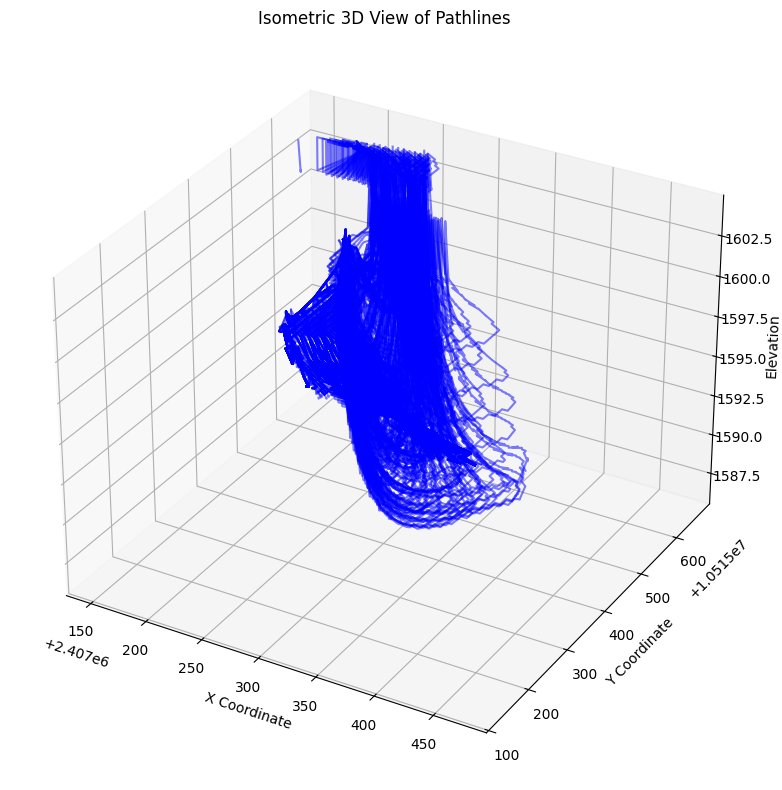

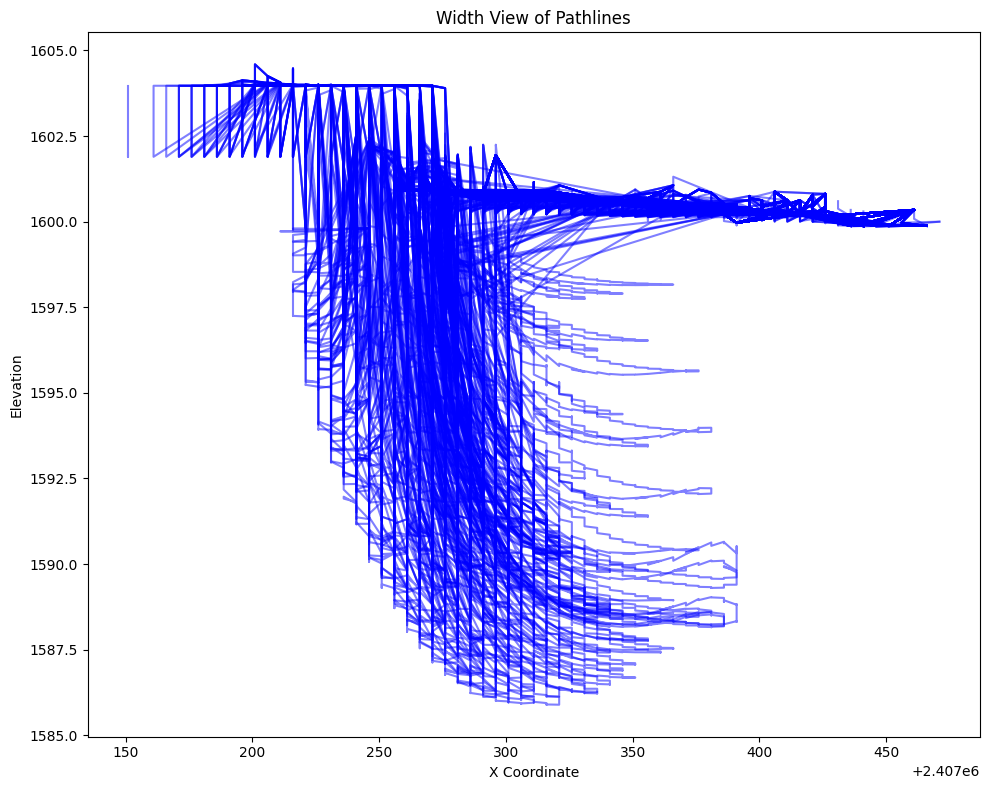

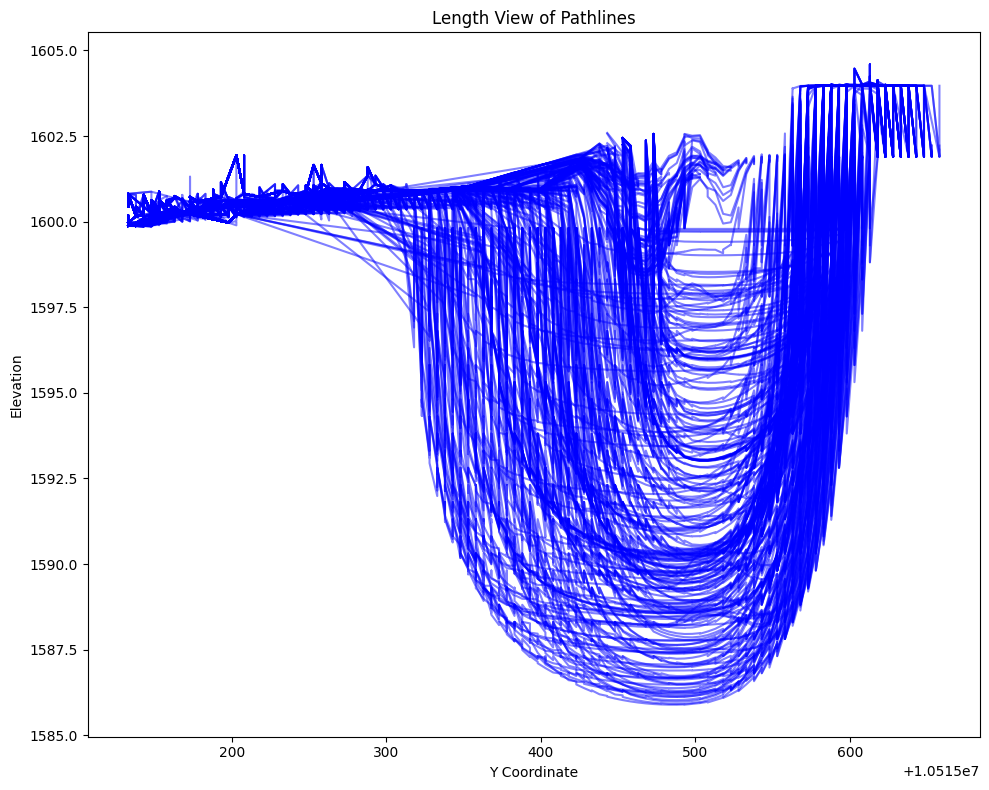

In [ ]:
## 3D Plotting of Pathlines
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for pid, group in df_prc.groupby('particleid'):
    ax.plot(group['x_coord'], group['y_coord'], group['z_elevation'], color='blue', alpha=0.5)

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Elevation')
ax.set_title('Isometric 3D View of Pathlines')
plt.tight_layout()
plt.show()

# Longitudinal Section Plot (X vs Elevation)
fig, ax = plt.subplots(figsize=(10, 8))
for pid, group in df_prc.groupby('particleid'):
    ax.plot(group['x_coord'], group['z_elevation'], color='blue', alpha=0.5)
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Elevation')
ax.set_title('Width View of Pathlines')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
for pid, group in df_prc.groupby('particleid'):
    ax.plot(group['y_coord'], group['z_elevation'], color='blue', alpha=0.5)
ax.set_xlabel('Y Coordinate')
ax.set_ylabel('Elevation')
ax.set_title('Length View of Pathlines')
plt.tight_layout()
plt.show()

# Create Spatial Output Data

In [ ]:
# Clean up column names to less than 10 characters for ESRI
custom_map_points = {
    "row": "row",                         # model row
    "col": "col",                         # model col
    "z_elevation": "zelev",               # elevation
    "hyporheic_volume_cubic_ft": "hypvol_ft", # hyporheic vol (ft^3)
    "cell_residence_time_days": "cel_res_t", # cell res time (days)
    "total_residence_time_days": "res_time", # total res time (days)
    "length_in_cell_ft": "Len_ft",      # length in cell (ft)
    "total_length_ft": "tot_len_ft",      # total length (ft)
    "particle_velocity_ft_per_day": "vel_ftday", # velocity (ft/day)
    "flow_rate_cubic_ft_per_day": "flow_ftday", # flow rate (ft^3/day)
    "hydraulic_gradient": "hyd_grad",     # hydraulic gradient
    "hydraulic_head": "hyd_head",         # head
    "starting_hydraulic_head": "head_strt", # start head
    "ending_hydraulic_head": "head_end",     # end head
    "x_coord": "xcoord",                  # x coordinate
    "y_coord": "ycoord",                  # y coordinate
    "total_volume_cubic_ft": "tot_vol_ft", # total vol (ft^3)
    # Add others as needed
}

custom_map_summary = {
    "particleid": "particleid",              # particle id
    "total_volume_cubic_ft": "tot_vol_ft",# total volume (ft^3)
    "hyporheic_volume_cubic_ft": "hypvol_ft", # hyporheic volume (ft^3)
    "starting_hydraulic_head": "head_strt",   # start head
    "ending_hydraulic_head": "head_end",      # end head
    "min_elevation_per_particle": "min_elev", # min elevation
    "total_residence_time_per_particle": "res_time", # residence time
    "total_length_per_particle": "tot_len_ft",# total length (ft)
    "average_particle_velocity_per_particle": "vel_ftday", # velocity (ft/day)
    "average_flow_rate_per_particle": "flow_ftday",      # flow rate (ft^3/day)
}

df_particle_summary = df_particle_summary.rename(columns=custom_map_summary)
df_prc = df_prc.rename(columns=custom_map_points)

print([c for c in df_particle_summary.columns if len(c) > 10])
print([c for c in df_prc.columns if len(c) > 10])

['z_elevation', 'total_residence_time_days', 'total_length_ft', 'particle_velocity_ft_per_day', 'flow_rate_cubic_ft_per_day', 'hydraulic_gradient', 'x_cell_size_ft', 'y_cell_size_ft', 'z_cell_size_ft']
[]


In [ ]:
from rasterio.crs import CRS

# Need to create a set of points grouped by particleid and referenced to CRS
projection_file = "C:\\Users\\u4eeevmq\\Documents\\Python\\HyporheicFloPy\\CH00365\\RAS\\GIS_Data\\102739_TX_central.prj"
hec_ras_crs = CRS.from_string(open(projection_file).read().strip())

# Points GeoDataFrame
df_prc['geometry'] = df_prc.apply(lambda df_prc: Point(df_prc['xcoord'], df_prc['ycoord']), axis=1)
points_gdf = gpd.GeoDataFrame(df_prc, geometry='geometry', crs=hec_ras_crs)

# Lines GeoDataFrame
def make_linestring(group):
    group = group.sort_values('res_time')
    points = list(zip(group['xcoord'], group['ycoord']))
    if len(points) > 1:
        return LineString(points)
    else:
        return None  # Skip groups with <= 1 point

lines = df_prc.groupby('particleid').apply(make_linestring)
lines = lines.dropna()
lines = lines.reset_index()  # <-- This makes 'particleid' a column

lines_gdf = gpd.GeoDataFrame({'particleid': lines['particleid'], 'geometry': lines[0]}, crs=hec_ras_crs)
lines_gdf = lines_gdf.merge(df_particle_summary, on='particleid', how='left')



C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_34292\1991587211.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lines = df_prc.groupby('particleid').apply(make_linestring)


In [ ]:
# Reproject to WGS84 (EPSG:4326) for KML/KMZ export
points_gdf_wgs84 = points_gdf.to_crs(epsg=4326)
lines_gdf_wgs84 = lines_gdf.to_crs(epsg=4326)

# Save results as a shapefile (columns are limited to 10 characters)
points_gdf.to_file("Forward_hyporheic_points_HECRAS_CRS.shp", driver="ESRI Shapefile")
lines_gdf.to_file("Forward_hyporheic_pathlines_HECRAS_CRS.shp", driver="ESRI Shapefile")
points_gdf_wgs84.to_file("Forward_hyporheic_points.shp", driver="ESRI Shapefile")
lines_gdf_wgs84.to_file("Forward_hyporheic_pathlines.shp", driver="ESRI Shapefile")

# Export to KML
points_gdf_wgs84.to_file("Forward_hyporheic_points.kml", driver="KML")
lines_gdf_wgs84.to_file("Forward_hyporheic_pathlines.kml", driver="KML")

# Zip to KMZ
with zipfile.ZipFile("Forward_hyporheic_points.kmz", "w", zipfile.ZIP_DEFLATED) as kmz:
    kmz.write("Forward_hyporheic_points.kml", "Forward_hyporheic_points.kml")

with zipfile.ZipFile("Forward_hyporheic_pathlines.kmz", "w", zipfile.ZIP_DEFLATED) as kmz:
    kmz.write("Forward_hyporheic_pathlines.kml", "Forward_hyporheic_pathlines.kml")


C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_34292\3679767659.py:7: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lines_gdf.to_file("Forward_hyporheic_pathlines_HECRAS_CRS.shp", driver="ESRI Shapefile")
C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_34292\3679767659.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lines_gdf_wgs84.to_file("Forward_hyporheic_pathlines.shp", driver="ESRI Shapefile")


# Plot Results

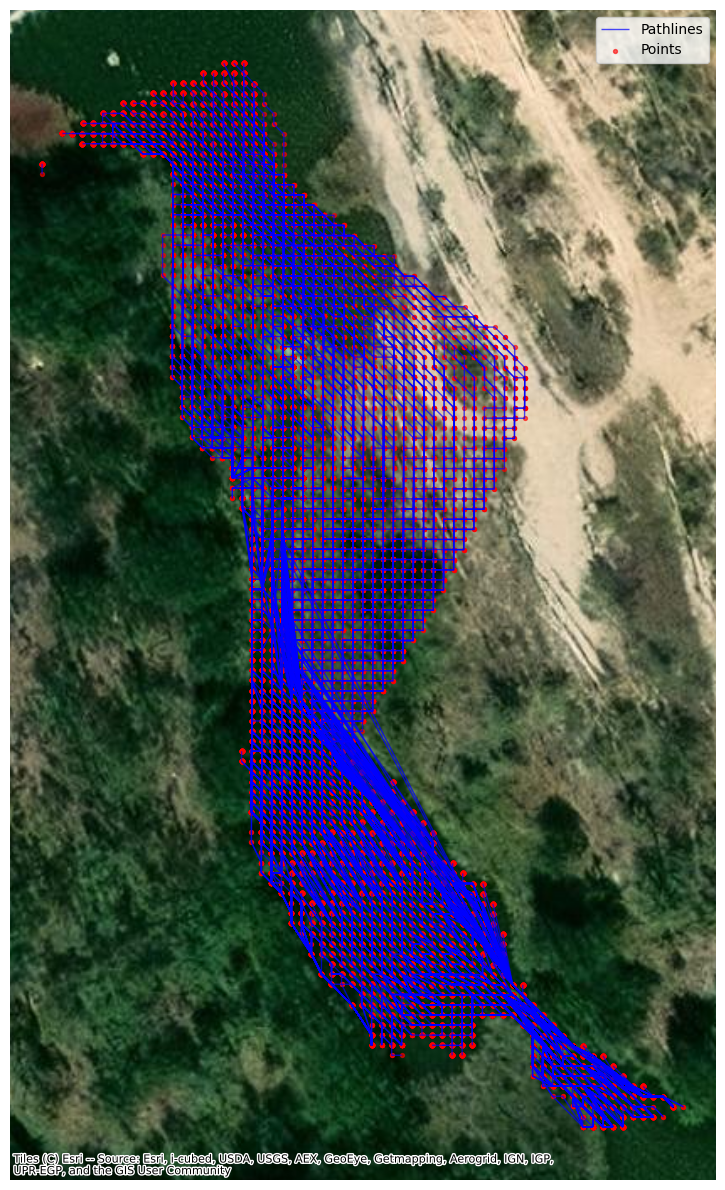

In [ ]:
# Reproject to Web Mercator (required for contextily)
points_gdf_web = points_gdf_wgs84.to_crs(epsg=3857)
lines_gdf_web = lines_gdf_wgs84.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))
lines_gdf_web.plot(ax=ax, color='blue', linewidth=1, alpha=0.7, label='Pathlines')
points_gdf_web.plot(ax=ax, color='red', markersize=8, alpha=0.6, label='Points')

# Add Esri satellite imagery
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)

ax.set_axis_off()
plt.legend()
plt.tight_layout()
plt.show()